# Data Wrangling: Laptop Pricing Dataset

This notebook demonstrates comprehensive data cleaning and transformation techniques applied to a laptop pricing dataset.

## Project Overview

The goal of this project is to clean, transform, and prepare a raw laptop pricing dataset for analysis. The workflow includes:

1. **Data Loading & Exploration**: Load and examine the dataset structure
2. **Missing Value Imputation**: Handle missing values appropriately
3. **Unit Conversion**: Standardize measurements to common units
4. **Data Normalization**: Scale numerical features
5. **Binning**: Convert continuous variables to categorical
6. **Feature Engineering**: Create indicator variables
7. **Data Export**: Save the cleaned dataset

---


In [2]:
import pandas as pd
import numpy as np

In [ ]:
# Load the raw dataset
# Input file: laptop_pricing_dataset_mod1.csv
file = "laptop_pricing_dataset.csv"
df = pd.read_csv(file)

# Display first few rows to understand the data structure
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Dataset shape: (238, 13)

First 5 rows:


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [4]:
# Explore dataset information and structure
# Check data types, non-null counts, and memory usage
print("Dataset Information:")
df.info()

print("\nLast 10 rows:")
df.tail(10)


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      238 non-null    int64  
 1   Manufacturer    238 non-null    object 
 2   Category        238 non-null    int64  
 3   Screen          238 non-null    object 
 4   GPU             238 non-null    int64  
 5   OS              238 non-null    int64  
 6   CPU_core        238 non-null    int64  
 7   Screen_Size_cm  234 non-null    float64
 8   CPU_frequency   238 non-null    float64
 9   RAM_GB          238 non-null    int64  
 10  Storage_GB_SSD  238 non-null    int64  
 11  Weight_kg       233 non-null    float64
 12  Price           238 non-null    int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 24.3+ KB

Last 10 rows:


,Unnamed: 0,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
228,228,HP,2,Full HD,2,1,5,31.750,2.3,8,256,1.26,2120
229,229,Dell,4,Full HD,2,1,5,35.560,2.5,8,256,1.36,2082
230,230,Dell,4,Full HD,2,1,5,NaN,2.5,8,256,1.36,1870
231,231,Dell,4,Full HD,2,1,7,35.560,2.8,8,256,1.36,2255
232,232,Toshiba,3,Full HD,2,1,5,33.782,2.3,8,256,1.20,1855
233,233,Lenovo,4,IPS Panel,2,1,7,35.560,2.6,8,256,1.70,1891
234,234,Toshiba,3,Full HD,2,1,5,33.782,2.4,8,256,1.20,1950
235,235,Lenovo,4,IPS Panel,2,1,5,30.480,2.6,8,256,1.36,2236
236,236,Lenovo,3,Full HD,3,1,5,39.624,2.5,6,256,2.40,883
237,237,Toshiba,3,Full HD,2,1,5,35.560,2.3,8,256,1.95,1499


In [5]:
# Remove unnecessary index column (Unnamed: 0)
# This column appears to be a duplicate index and is not needed for analysis
df.drop(columns=["Unnamed: 0"], inplace=True)

print("After removing 'Unnamed: 0' column:")
df.head(10)

After removing 'Unnamed: 0' column:


,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.560,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837
5,Dell,3,Full HD,1,1,5,39.624,1.6,8,256,2.20,1016
6,HP,3,Full HD,3,1,5,39.624,1.6,8,256,2.10,1117
7,Acer,3,IPS Panel,2,1,5,38.100,1.6,4,256,2.20,866
8,Dell,3,Full HD,1,1,5,39.624,2.5,4,256,2.30,812
9,Acer,3,IPS Panel,3,1,7,38.100,1.8,8,256,2.20,1068


In [6]:
# Round Screen_Size_cm values to 2 decimal places for consistency
# This improves readability and reduces floating-point precision issues
df['Screen_Size_cm'] = np.round(df['Screen_Size_cm'], 2)
print("Screen_Size_cm rounded to 2 decimal places:")
df.head()

Screen_Size_cm rounded to 2 decimal places:


,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.60,978
1,Dell,3,Full HD,1,1,3,39.62,2.0,4,256,2.20,634
2,Dell,3,Full HD,1,1,7,39.62,2.7,8,256,2.20,946
3,Dell,4,IPS Panel,2,1,5,33.78,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.62,1.8,8,256,1.91,837


In [7]:
# Find the most common Screen Size value
# This will be used to impute missing values in the Screen_Size_cm column
# Using mode (most frequent value) is appropriate for screen size as laptops tend to have standard sizes
comm = df['Screen_Size_cm'].value_counts().idxmax()
print(f"Most common Screen Size (cm): {comm}")
comm



Most common Screen Size (cm): 39.62


np.float64(39.62)

In [8]:
# Impute missing values in Screen_Size_cm with the most common value
# This approach is suitable when missing values are missing at random (MAR)
df['Screen_Size_cm'] = df['Screen_Size_cm'].replace(np.nan, comm)
print("After imputing missing Screen_Size_cm values:")
df.tail(10)

After imputing missing Screen_Size_cm values:


,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
228,HP,2,Full HD,2,1,5,31.75,2.3,8,256,1.26,2120
229,Dell,4,Full HD,2,1,5,35.56,2.5,8,256,1.36,2082
230,Dell,4,Full HD,2,1,5,39.62,2.5,8,256,1.36,1870
231,Dell,4,Full HD,2,1,7,35.56,2.8,8,256,1.36,2255
232,Toshiba,3,Full HD,2,1,5,33.78,2.3,8,256,1.20,1855
233,Lenovo,4,IPS Panel,2,1,7,35.56,2.6,8,256,1.70,1891
234,Toshiba,3,Full HD,2,1,5,33.78,2.4,8,256,1.20,1950
235,Lenovo,4,IPS Panel,2,1,5,30.48,2.6,8,256,1.36,2236
236,Lenovo,3,Full HD,3,1,5,39.62,2.5,6,256,2.40,883
237,Toshiba,3,Full HD,2,1,5,35.56,2.3,8,256,1.95,1499


In [9]:
# Check dataset status - Note: Still missing values in Weight_kg column
df.info()

# Calculate the mean weight for imputation
# Using mean is appropriate for continuous variables like weight
mean_wt = df['Weight_kg'].astype(float).mean(axis=0)
print(f"\nAverage Weight (kg): {mean_wt:.4f}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    object 
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    object 
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  238 non-null    float64
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       233 non-null    float64
 11  Price           238 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 22.4+ KB

Average Weight (kg): 1.8622


In [10]:
# Impute missing values in Weight_kg with the mean value
# Mean imputation is standard practice for continuous variables
df['Weight_kg'] = df['Weight_kg'].replace(np.nan, mean_wt)

# Verify that all missing values have been handled
print("Dataset after imputing Weight_kg missing values:")
df.info()

Dataset after imputing Weight_kg missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Manufacturer    238 non-null    object 
 1   Category        238 non-null    int64  
 2   Screen          238 non-null    object 
 3   GPU             238 non-null    int64  
 4   OS              238 non-null    int64  
 5   CPU_core        238 non-null    int64  
 6   Screen_Size_cm  238 non-null    float64
 7   CPU_frequency   238 non-null    float64
 8   RAM_GB          238 non-null    int64  
 9   Storage_GB_SSD  238 non-null    int64  
 10  Weight_kg       238 non-null    float64
 11  Price           238 non-null    int64  
dtypes: float64(3), int64(7), object(2)
memory usage: 22.4+ KB


In [11]:
# Display last 10 rows to verify the data cleaning steps
df.tail(10)

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
228,HP,2,Full HD,2,1,5,31.75,2.3,8,256,1.26,2120
229,Dell,4,Full HD,2,1,5,35.56,2.5,8,256,1.36,2082
230,Dell,4,Full HD,2,1,5,39.62,2.5,8,256,1.36,1870
231,Dell,4,Full HD,2,1,7,35.56,2.8,8,256,1.36,2255
232,Toshiba,3,Full HD,2,1,5,33.78,2.3,8,256,1.20,1855
233,Lenovo,4,IPS Panel,2,1,7,35.56,2.6,8,256,1.70,1891
234,Toshiba,3,Full HD,2,1,5,33.78,2.4,8,256,1.20,1950
235,Lenovo,4,IPS Panel,2,1,5,30.48,2.6,8,256,1.36,2236
236,Lenovo,3,Full HD,3,1,5,39.62,2.5,6,256,2.40,883
237,Toshiba,3,Full HD,2,1,5,35.56,2.3,8,256,1.95,1499


In [12]:
# Verify data types are correct
# All features should have appropriate data types for their content
print("Data types of all columns:")
df.dtypes


Data types of all columns:


Manufacturer       object
Category            int64
Screen             object
GPU                 int64
OS                  int64
CPU_core            int64
Screen_Size_cm    float64
CPU_frequency     float64
RAM_GB              int64
Storage_GB_SSD      int64
Weight_kg         float64
Price               int64
dtype: object

## Unit Conversion Reference

Conversion factors for standardizing measurements:
- **1 inch = 2.54 cm** (for screen size conversion)
- **1 kg = 2.205 pounds** (for weight conversion)

These conversions will help standardize the dataset to commonly used units.

In [13]:
# Standardize units and column names
# Convert screen size from cm to inches (more commonly used unit)
df['Screen_Size_cm'] = df['Screen_Size_cm'] / 2.54
df.rename(columns={"Screen_Size_cm": "Screen_Size_inch"}, inplace=True)

# Convert weight from kg to pounds (more commonly used unit in many markets)
df['Weight_kg'] = df['Weight_kg'] * 2.205
df.rename(columns={"Weight_kg": "Weight_Pounds"}, inplace=True)

print("After unit conversion and column renaming:")
df.head()

After unit conversion and column renaming:


,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_Pounds,Price
0,Acer,4,IPS Panel,2,1,5,14.000000,1.6,8,256,3.52800,978
1,Dell,3,Full HD,1,1,3,15.598425,2.0,4,256,4.85100,634
2,Dell,3,Full HD,1,1,7,15.598425,2.7,8,256,4.85100,946
3,Dell,4,IPS Panel,2,1,5,13.299213,1.6,8,128,2.69010,1244
4,HP,4,Full HD,2,1,7,15.598425,1.8,8,256,4.21155,837


## Data Normalization

Data normalization is a scaling technique used to bring values into a common range, typically [0, 1]. 
This is important for:
- Machine learning algorithms that are sensitive to feature scales
- Comparing attributes on different scales
- Improving model convergence

We'll normalize the "CPU_frequency" attribute using min-max normalization (dividing by maximum value).

In [14]:
# Normalize CPU_frequency by dividing by the maximum value
# This scales all values to the range [0, 1]
df['CPU_frequency'] = df['CPU_frequency'] / df['CPU_frequency'].max()

print("After normalizing CPU_frequency (values now between 0 and 1):")
df.head()

After normalizing CPU_frequency (values now between 0 and 1):


,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_Pounds,Price
0,Acer,4,IPS Panel,2,1,5,14.000000,0.551724,8,256,3.52800,978
1,Dell,3,Full HD,1,1,3,15.598425,0.689655,4,256,4.85100,634
2,Dell,3,Full HD,1,1,7,15.598425,0.931034,8,256,4.85100,946
3,Dell,4,IPS Panel,2,1,5,13.299213,0.551724,8,128,2.69010,1244
4,HP,4,Full HD,2,1,7,15.598425,0.620690,8,256,4.21155,837


## Binning Continuous Variables

Binning (also called discretization) converts continuous variables into categorical variables by:
- Dividing the range of values into intervals (bins)
- Assigning each value to a bin
- Creating categorical labels for each bin

Benefits:
- Simplifies analysis
- Reduces noise and overfitting
- Makes patterns more visible
- Useful for certain machine learning algorithms

We'll create 3 bins for the "Price" attribute: **Low**, **Medium**, and **High**.

In [15]:
# Create 3 bins for Price using equal-width binning
# np.linspace creates 4 edges (0, 1, 2, 3) which creates 3 bins
bins = np.linspace(min(df['Price']), max(df['Price']), 4)
groups = ["Low", "Medium", "High"]  # Fixed: Changed "Max" to "High" for consistency

# Use pd.cut to assign each price to a bin
# include_lowest=True ensures the minimum value is included in the first bin
df["Price_Binned"] = pd.cut(df['Price'], bins, labels=groups, include_lowest=True)

print("Price distribution in bins:")
print(df['Price_Binned'].value_counts().sort_index())
print("\nLast 10 rows with Price_Binned column:")
df.tail(10)

Price distribution in bins:
Price_Binned
Low       160
Medium     72
High        6
Name: count, dtype: int64

Last 10 rows with Price_Binned column:


,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_Pounds,Price,Price_Binned
228,HP,2,Full HD,2,1,5,12.500000,0.793103,8,256,2.77830,2120,Medium
229,Dell,4,Full HD,2,1,5,14.000000,0.862069,8,256,2.99880,2082,Medium
230,Dell,4,Full HD,2,1,5,15.598425,0.862069,8,256,2.99880,1870,Medium
231,Dell,4,Full HD,2,1,7,14.000000,0.965517,8,256,2.99880,2255,Medium
232,Toshiba,3,Full HD,2,1,5,13.299213,0.793103,8,256,2.64600,1855,Medium
233,Lenovo,4,IPS Panel,2,1,7,14.000000,0.896552,8,256,3.74850,1891,Medium
234,Toshiba,3,Full HD,2,1,5,13.299213,0.827586,8,256,2.64600,1950,Medium
235,Lenovo,4,IPS Panel,2,1,5,12.000000,0.896552,8,256,2.99880,2236,Medium
236,Lenovo,3,Full HD,3,1,5,15.598425,0.862069,6,256,5.29200,883,Low
237,Toshiba,3,Full HD,2,1,5,14.000000,0.793103,8,256,4.29975,1499,Low


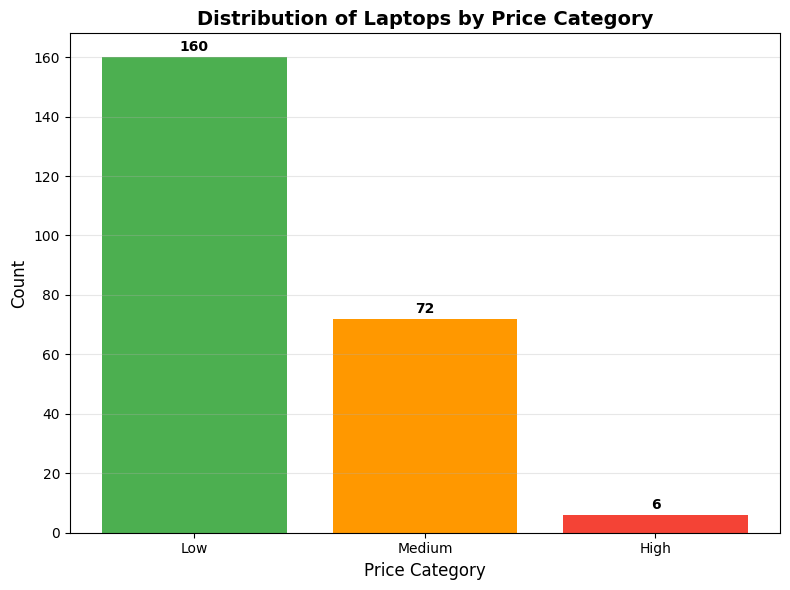

In [21]:
# Visualize the Price bins using a bar chart
import matplotlib.pyplot as plt

# Get value counts for each bin and sort by bin order
bin_counts = df['Price_Binned'].value_counts().sort_index()

# Create bar plot
plt.figure(figsize=(8, 6))
plt.bar(bin_counts.index, bin_counts.values, color=['#4CAF50', '#FF9800', '#F44336'])
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Distribution of Laptops by Price Category', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(bin_counts.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Creating Indicator Variables (Dummy Variables)

Indicator variables (also called dummy variables or one-hot encoding) convert categorical variables into binary (0/1) variables.

Benefits:
- Makes categorical data usable in mathematical models
- Each category gets its own column
- Prevents ordinal assumptions (no implied ordering)

We'll convert the "Screen" attribute into two indicator variables:
- **Screen_Full_HD**: 1 if screen is Full HD, 0 otherwise
- **Screen_IPS_Panel**: 1 if screen is IPS Panel, 0 otherwise

Then we'll drop the original "Screen" column.

In [17]:
# Create indicator variables from the Screen column using one-hot encoding
dummies = pd.get_dummies(df['Screen'], prefix='Screen')

# Rename columns to match desired naming convention
dummies.rename(columns={
    "Screen_Full HD": "Screen_Full_HD",
    "Screen_IPS Panel": "Screen_IPS_Panel"
}, inplace=True)

print("Indicator variables created:")
dummies.head()

# Merge the indicator variables with the main dataframe
df = pd.concat([df, dummies], axis=1)

# Drop the original Screen column as it's now represented by indicator variables
df.drop(columns=['Screen'], inplace=True)

print("\nDataframe after adding indicator variables and dropping Screen column:")
df.head()


Indicator variables created:

Dataframe after adding indicator variables and dropping Screen column:


,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_Pounds,Price,Price_Binned,Screen_Full_HD,Screen_IPS_Panel
0,Acer,4,2,1,5,14.000000,0.551724,8,256,3.52800,978,Low,False,True
1,Dell,3,1,1,3,15.598425,0.689655,4,256,4.85100,634,Low,True,False
2,Dell,3,1,1,7,15.598425,0.931034,8,256,4.85100,946,Low,True,False
3,Dell,4,2,1,5,13.299213,0.551724,8,128,2.69010,1244,Low,False,True
4,HP,4,2,1,7,15.598425,0.620690,8,256,4.21155,837,Low,True,False


In [18]:
# Final data summary and verification
print("=" * 60)
print("FINAL CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst few rows of cleaned dataset:")
df.head()


FINAL CLEANED DATASET SUMMARY

Dataset Shape: (238, 14)
Rows: 238, Columns: 14

Column Names:
['Manufacturer', 'Category', 'GPU', 'OS', 'CPU_core', 'Screen_Size_inch', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_Pounds', 'Price', 'Price_Binned', 'Screen_Full_HD', 'Screen_IPS_Panel']

Data Types:
Manufacturer          object
Category               int64
GPU                    int64
OS                     int64
CPU_core               int64
Screen_Size_inch     float64
CPU_frequency        float64
RAM_GB                 int64
Storage_GB_SSD         int64
Weight_Pounds        float64
Price                  int64
Price_Binned        category
Screen_Full_HD          bool
Screen_IPS_Panel        bool
dtype: object

Missing Values:
Manufacturer        0
Category            0
GPU                 0
OS                  0
CPU_core            0
Screen_Size_inch    0
CPU_frequency       0
RAM_GB              0
Storage_GB_SSD      0
Weight_Pounds       0
Price               0
Price_Binned   

,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_Pounds,Price,Price_Binned,Screen_Full_HD,Screen_IPS_Panel
0,Acer,4,2,1,5,14.000000,0.551724,8,256,3.52800,978,Low,False,True
1,Dell,3,1,1,3,15.598425,0.689655,4,256,4.85100,634,Low,True,False
2,Dell,3,1,1,7,15.598425,0.931034,8,256,4.85100,946,Low,True,False
3,Dell,4,2,1,5,13.299213,0.551724,8,128,2.69010,1244,Low,False,True
4,HP,4,2,1,7,15.598425,0.620690,8,256,4.21155,837,Low,True,False


In [19]:
# Export the cleaned and wrangled dataset to CSV
output_file = "Wraggled_Laptops_Data.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned dataset successfully exported to: {output_file}")
print(f"Total rows exported: {len(df)}")
print(f"Total columns exported: {len(df.columns)}")


Cleaned dataset successfully exported to: Wraggled_Laptops_Data.csv
Total rows exported: 238
Total columns exported: 14
